# Lagos Real Estate EDA

**Objective:** understand pricing patterns, property distribution, and market structure in Lagos real estate listings.

This notebook follows a clean EDA flow: overview, pricing, location, property traits, segmentation, agent activity, correlation, and luxury-market checks.

## Imports and configurations

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from pathlib import Path

In [40]:
plt.style.use('seaborn-v0_8-whitegrid')
PRIMARY = '#0052CC'
SECONDARY = '#008DA6'
ACCENT = '#FF8B00'
HIGHLIGHT = '#6554C0'
GOLD = '#FFAB00'
DANGER = '#DE350B'
SLATE = '#42526E'
plt.rcParams['axes.prop_cycle'] = cycler(color=[PRIMARY, SECONDARY, ACCENT, HIGHLIGHT, GOLD, SLATE])
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## 1. Load data and quick quality check

In [41]:
df = pd.read_csv('../data/processed/lagos_real_estate_market_data_cleaned.csv')
df = df.rename(columns={'type': 'status'}) #renaming the 'type' column to 'status' for clarity. 
df['price'] = pd.to_numeric(df['price'], errors='coerce') # making this numeric so I can do compute
df_eda = df.drop_duplicates(subset=['listing_url']).copy()
df_eda['log_price'] = np.log1p(df_eda['price']) #log transformation to manage skewness and for more intelligeble visuals

print(f'Raw rows: {len(df):,}')
print(f'Rows used for analysis: {len(df_eda):,}')
print(f'Duplicate listing URLs in raw data: {df.duplicated(subset=["listing_url"]).sum():,}')
print(f'Missing values in analysis frame: {int(df_eda.isna().sum().sum()):,}')
df_eda.head()

Raw rows: 653
Rows used for analysis: 652
Duplicate listing URLs in raw data: 1
Missing values in analysis frame: 0


,status,kind,price,title,location,beds,baths,agent,listing_url,district,log_price
0,For Rent,Apartment,"20,000,000.00",4 Units of 3 Bedroom Apartments in Lekki phase 1,Lekki Phase 1,3.00,3.00,Chinenye,https://cwlagos.com/property/4-units-of-3-bedr...,Lekki,16.81
1,For Sale,Detached Duplex,"1,500,000,000.00",Luxury 5 Bedroom Fully Detached House in Lekki...,Lekki Phase 1,5.00,5.00,Chinenye,https://cwlagos.com/property/luxury-5-bedroom-...,Lekki,21.13
2,For Rent,Apartment,"45,000,000.00",Furnished 3 Bedroom Apartment in Ikoyi,Banana Island,3.00,3.00,Adaeze,https://cwlagos.com/property/furnished-3-bedro...,Ikoyi,17.62
3,For Rent,Apartment,"89,408,528.00",Luxury 3-Bedroom Apartment in Ikoyi,Banana Island,3.00,3.00,Adaeze,https://cwlagos.com/property/luxury-3-bedroom-...,Ikoyi,18.31
4,For Rent,Commercial,"30,000,000.00",4 Bedroom Apartment for Commercial Use in VI,Victoria Island,0.00,0.00,Nadi,https://cwlagos.com/property/4-bedroom-apartme...,Victoria Island,17.22


In [42]:
# A general overview
overview = pd.DataFrame({
    'metric': ['Rows', 'Columns', 'Duplicate listing URLs', 'Missing values', 'Unique status', 'Unique kind', 'Unique location', 'Unique district'],
    'value': [len(df_eda), df_eda.shape[1], df.duplicated(subset=['listing_url']).sum(), int(df_eda.isna().sum().sum()), df_eda['status'].nunique(), df_eda['kind'].nunique(), df_eda['location'].nunique(), df_eda['district'].nunique()]
})
overview

,metric,value
0,Rows,652
1,Columns,11
2,Duplicate listing URLs,1
3,Missing values,0
4,Unique status,3
5,Unique kind,11
6,Unique location,21
7,Unique district,4


In [43]:
df_eda.dtypes.rename('dtype').to_frame()

df_eda[['status', 'kind', 'location', 'district']].nunique().rename('unique_count').to_frame()

,unique_count
status,3
kind,11
location,21
district,4


In [44]:
""" 
I stored the important statistics in variables to make it easier to reference them in the
visualizations and to make whole eda look neater...
"""

median_price = df_eda['price'].median()
q1 = df_eda['price'].quantile(0.25)
q3 = df_eda['price'].quantile(0.75)
luxury_threshold = df_eda['price'].quantile(0.99) # I created a threshold for luxury properties using the top 1% of the prices 
location_counts = df_eda['location'].value_counts()
median_by_location = df_eda.groupby('location')['price'].median().sort_values(ascending=False)
district_counts = df_eda['district'].value_counts()
median_by_district = df_eda.groupby('district')['price'].median().sort_values(ascending=False)
kind_counts = df_eda['kind'].value_counts()
median_by_kind = df_eda.groupby('kind')['price'].median().sort_values(ascending=False)
agent_counts = df_eda['agent'].value_counts()
agent_medians = df_eda.groupby('agent')['price'].median().sort_values(ascending=False)

## 2. Price landscape

In [45]:
price_summary = df_eda['price'].describe(percentiles=[0.25, 0.5, 0.75]).to_frame()
price_summary

,price
count,652.00
mean,"437,592,656.56"
std,"1,111,731,813.58"
min,"150,000.00"
25%,"25,000,000.00"
50%,"115,020,632.50"
75%,"450,000,000.00"
max,"15,000,000,000.00"


In [46]:
print(f'Median price: ₦{df_eda["price"].median():,.0f}')
print(f'Q1: ₦{df_eda["price"].quantile(0.25):,.0f}')
print(f'Q3: ₦{df_eda["price"].quantile(0.75):,.0f}')
print(f'Min price: ₦{df_eda["price"].min():,.0f}')
print(f'Max price: ₦{df_eda["price"].max():,.0f}')

Median price: ₦115,020,632
Q1: ₦25,000,000
Q3: ₦450,000,000
Min price: ₦150,000
Max price: ₦15,000,000,000


### Plot for visualizing the price distribution

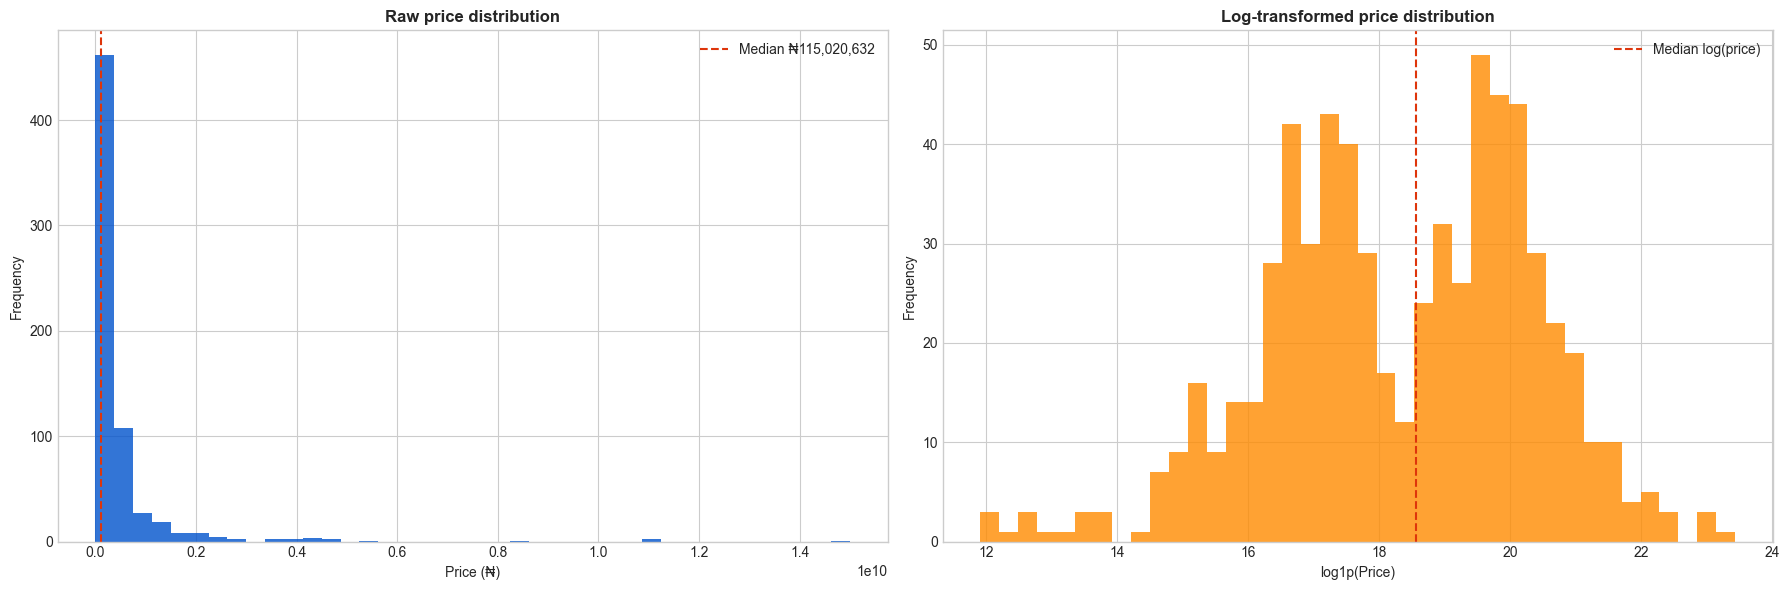

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].hist(df_eda['price'], bins=40, color=PRIMARY, alpha=0.8)
axes[0].axvline(df_eda['price'].median(), color=DANGER, linestyle='--', label=f'Median ₦{df_eda["price"].median():,.0f}')
axes[0].set_title('Raw price distribution')
axes[0].set_xlabel('Price (₦)')
axes[0].set_ylabel('Frequency')
axes[0].legend() 

axes[1].hist(df_eda['log_price'], bins=40, color=ACCENT, alpha=0.8)
axes[1].axvline(df_eda['log_price'].median(), color=DANGER, linestyle='--', label='Median log(price)')
axes[1].set_title('Log-transformed price distribution')
axes[1].set_xlabel('log1p(Price)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/price_distribution_histogram.png') #saving the figure for use in the report.
plt.show() # this shows the price distribution in an histogram in both raw and log-transformed forms.

/var/folders/rm/gc964zzn5c53102kbp7_hk4c0000gn/T/ipykernel_48462/1904689427.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([df_eda.loc[df_eda['status'] == s, 'price'] for s in status_order], labels=status_order, showfliers=False)
/var/folders/rm/gc964zzn5c53102kbp7_hk4c0000gn/T/ipykernel_48462/1904689427.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df_eda.loc[df_eda['status'] == s, 'log_price'] for s in status_order], labels=status_order, showfliers=False)


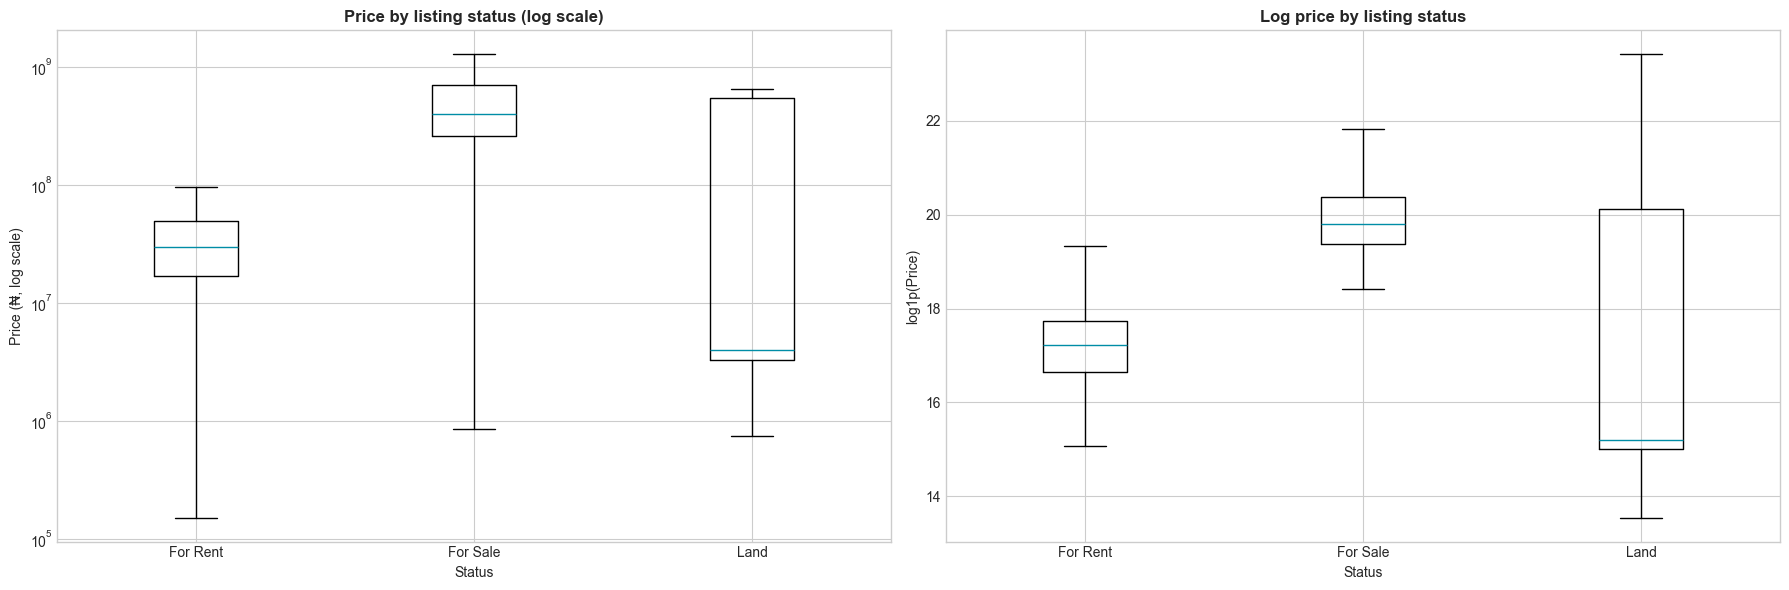

In [48]:
status_order = ['For Rent', 'For Sale', 'Land']
status_order = [s for s in status_order if s in df_eda['status'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].boxplot([df_eda.loc[df_eda['status'] == s, 'price'] for s in status_order], labels=status_order, showfliers=False)
axes[0].set_yscale('log')
axes[0].set_title('Price by listing status (log scale)')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Price (₦, log scale)')

axes[1].boxplot([df_eda.loc[df_eda['status'] == s, 'log_price'] for s in status_order], labels=status_order, showfliers=False)
axes[1].set_title('Log price by listing status')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout()
plt.savefig('../reports/figures/price_distribution_boxplot.png', dpi=300) #saving the figure for use in the report.
plt.show()# the price distibution in a boxplot to understand the outliers better.

## 3. Location and district analysis

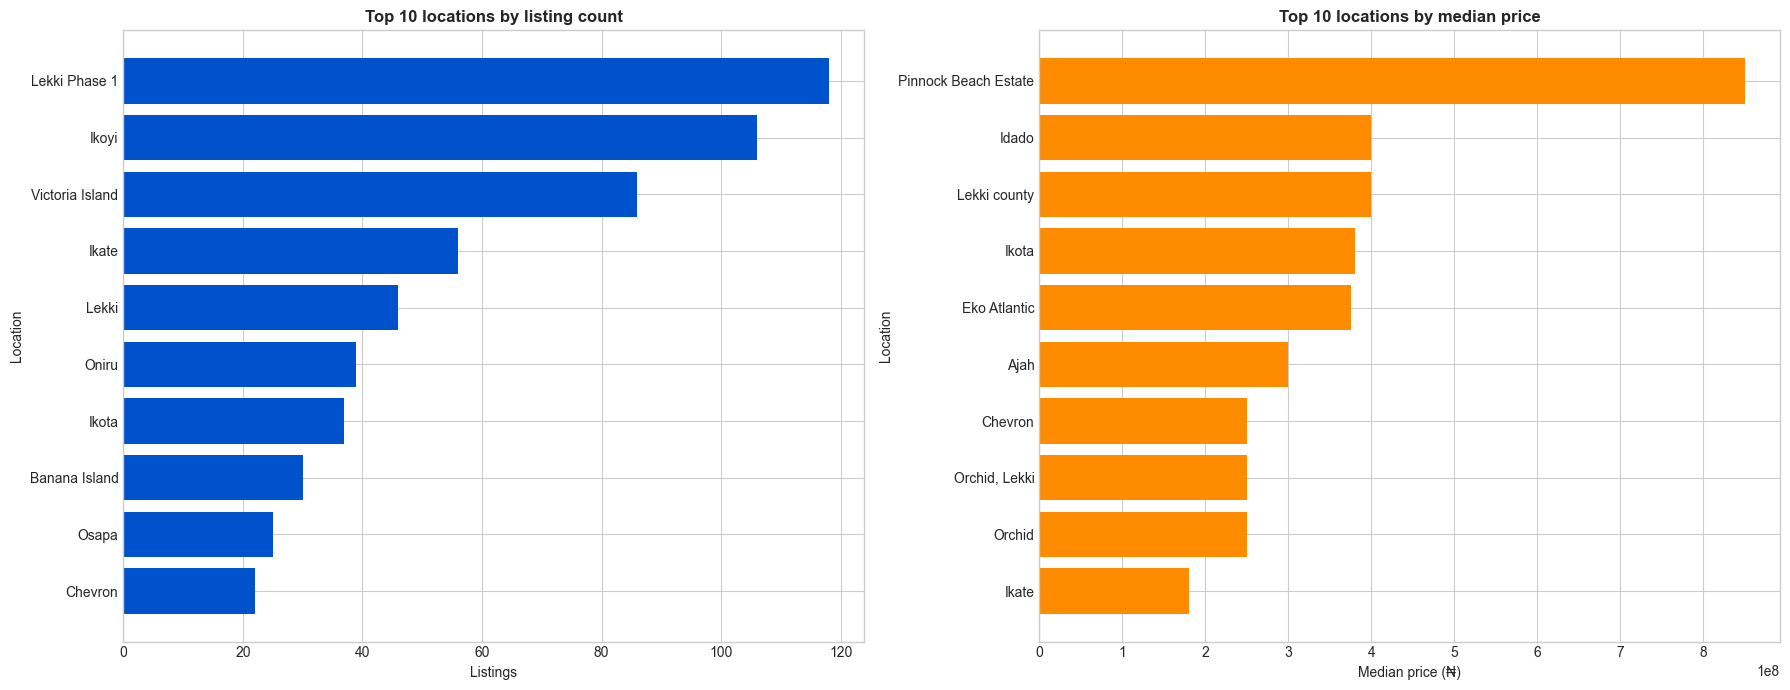

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
loc_count = location_counts.head(10).sort_values()
axes[0].barh(loc_count.index, loc_count.values, color=PRIMARY)
axes[0].set_title('Top 10 locations by listing count')
axes[0].set_xlabel('Listings')
axes[0].set_ylabel('Location')

loc_median = median_by_location.head(10).sort_values()
axes[1].barh(loc_median.index, loc_median.values, color=ACCENT)
axes[1].set_title('Top 10 locations by median price')
axes[1].set_xlabel('Median price (₦)')
axes[1].set_ylabel('Location')

plt.tight_layout()
plt.savefig('../reports/figures/locations_by_listing_count&median_price.png', dpi=300) #saving the figure for use in the report.
plt.show() # plots of the locations and the median price in the top 10 locations.

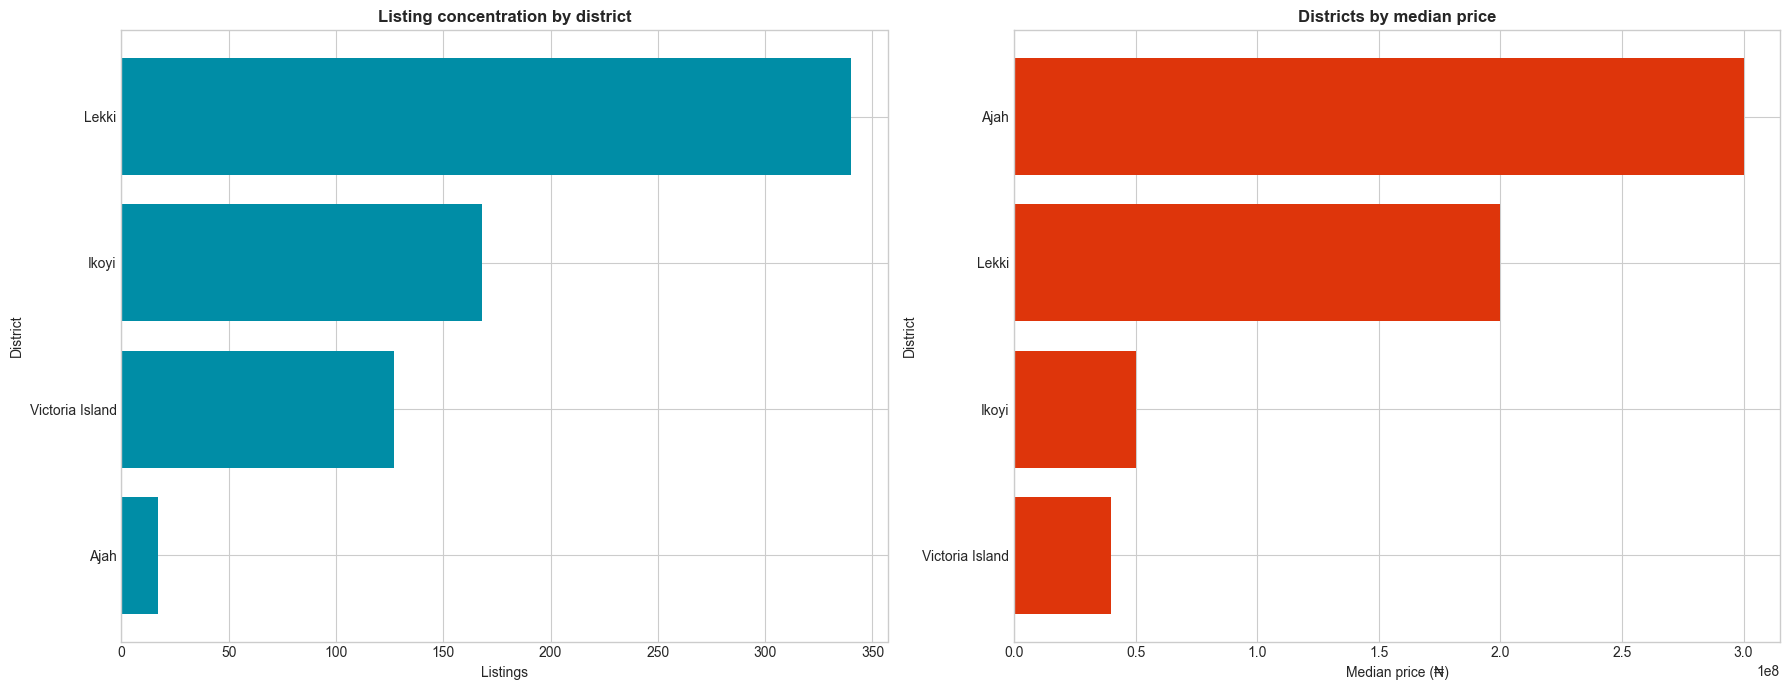

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
dist_count = district_counts.sort_values()
axes[0].barh(dist_count.index, dist_count.values, color=SECONDARY)
axes[0].set_title('Listing concentration by district')
axes[0].set_xlabel('Listings')
axes[0].set_ylabel('District')

dist_median = median_by_district.sort_values()
axes[1].barh(dist_median.index, dist_median.values, color=DANGER)
axes[1].set_title('Districts by median price')
axes[1].set_xlabel('Median price (₦)')
axes[1].set_ylabel('District')

plt.tight_layout()
plt.savefig('../reports/figures/districts_by_listing_count&median_price.png', dpi=300) #saving the figure for use in the report.
plt.show() # the graph of listing concentration by district and district by median price.

/var/folders/rm/gc964zzn5c53102kbp7_hk4c0000gn/T/ipykernel_48462/1340959719.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=top_locations, showfliers=False)


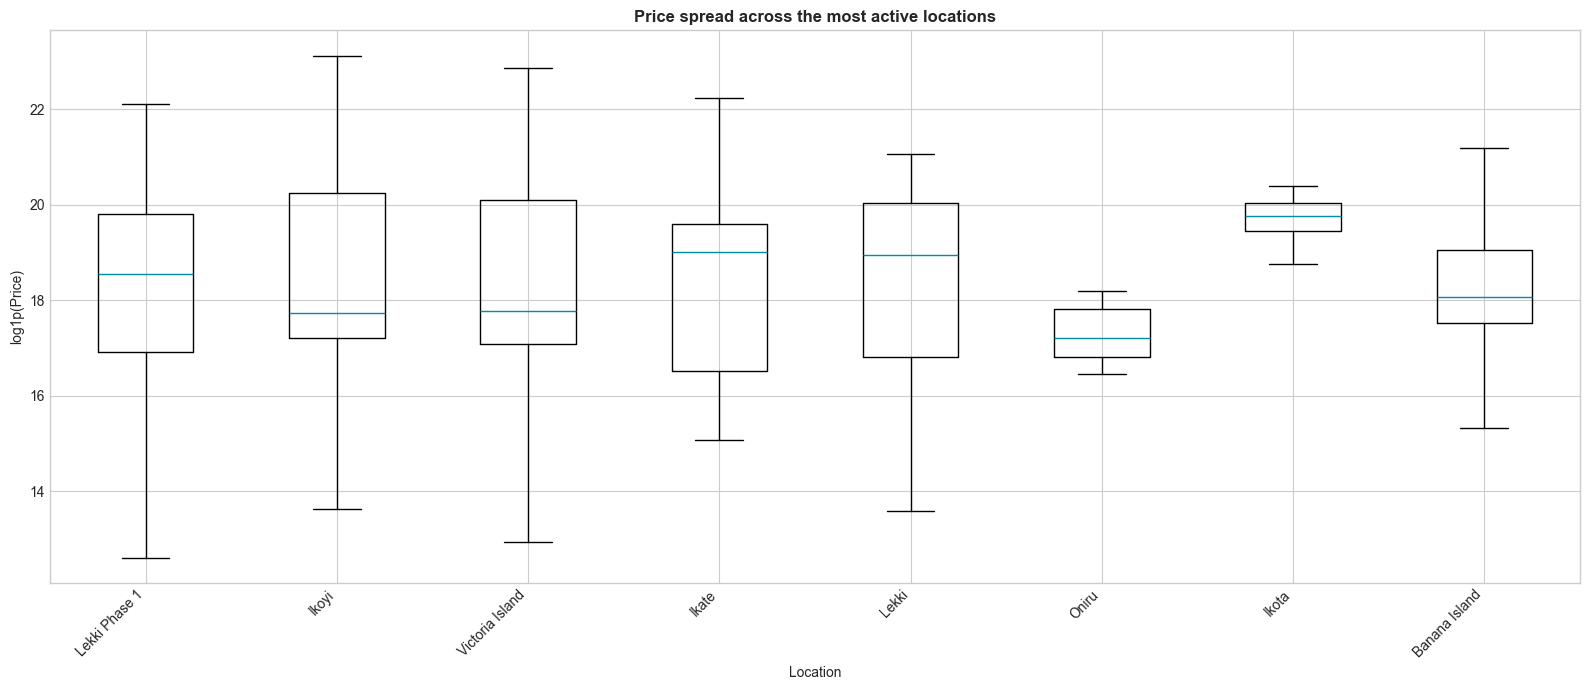

In [51]:
top_locations = location_counts.head(8).index
location_subset = df_eda[df_eda['location'].isin(top_locations)]
data = [location_subset.loc[location_subset['location'] == loc, 'log_price'] for loc in top_locations]

fig, ax = plt.subplots(figsize=(16, 7))
ax.boxplot(data, labels=top_locations, showfliers=False)
ax.set_title('Price spread across the most active locations')
ax.set_xlabel('Location')
ax.set_ylabel('log1p(Price)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/price_spread_top_locations.png', dpi=300) #saving the figure for use in the report.
plt.show()

## 4. Property characteristics

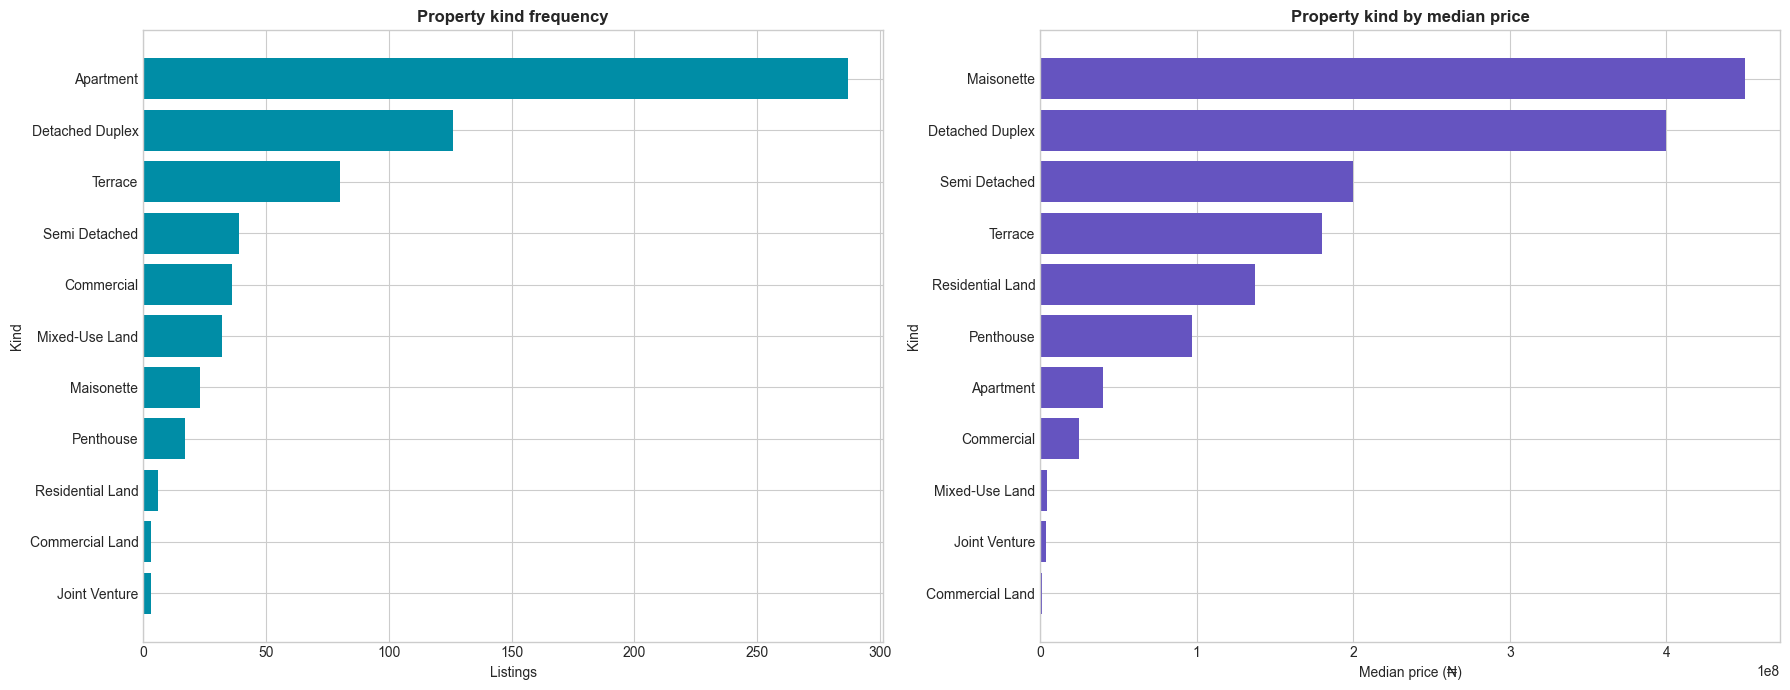

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
kind_count = kind_counts.sort_values()
axes[0].barh(kind_count.index, kind_count.values, color=SECONDARY)
axes[0].set_title('Property kind frequency')
axes[0].set_xlabel('Listings')
axes[0].set_ylabel('Kind')

kind_median = median_by_kind.sort_values()
axes[1].barh(kind_median.index, kind_median.values, color=HIGHLIGHT)
axes[1].set_title('Property kind by median price')
axes[1].set_xlabel('Median price (₦)')
axes[1].set_ylabel('Kind')

plt.tight_layout()
plt.savefig('../reports/figures/kind_by_listing_count&median_price.png', dpi=300) #saving the figure for use in the report.
plt.show()

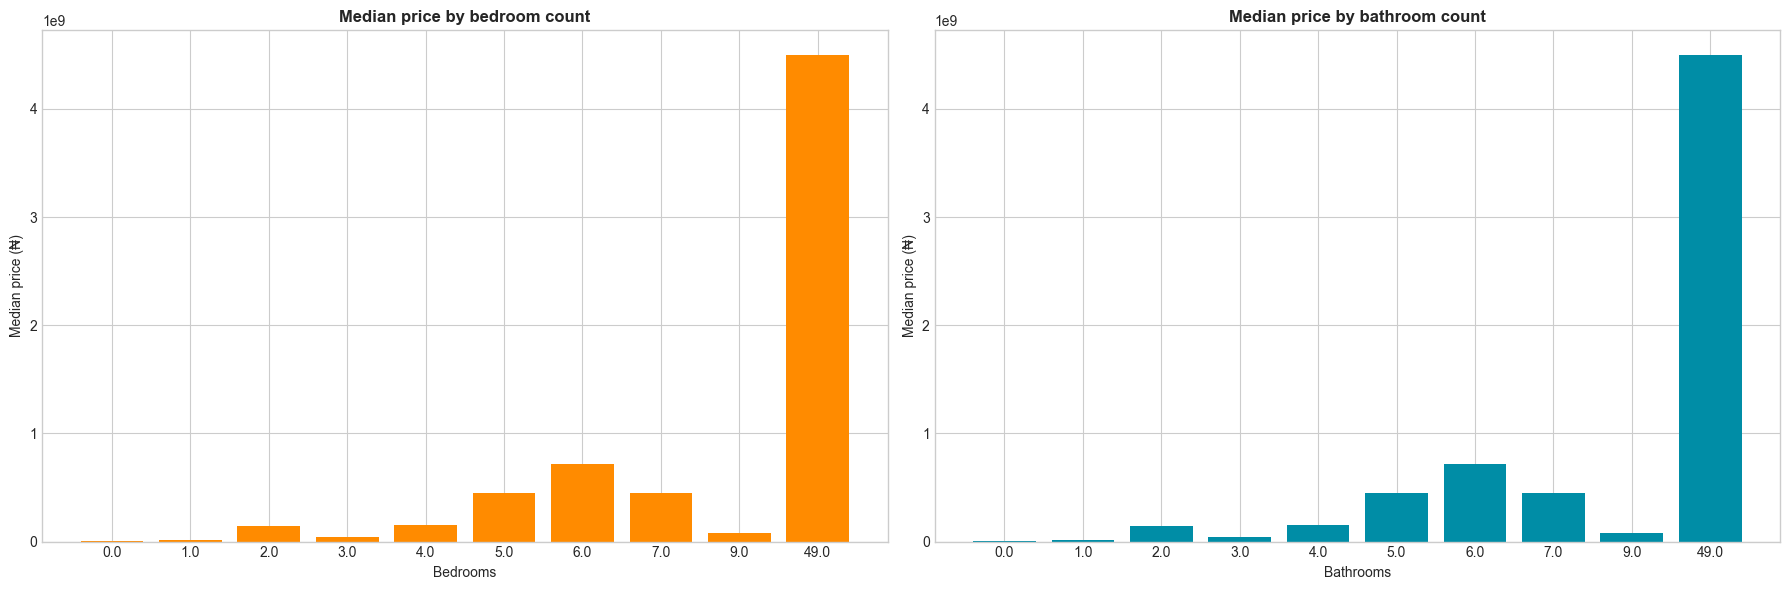

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

beds_median = df_eda.groupby('beds', dropna=False)['price'].median().sort_index()
ax[0].bar([str(x) for x in beds_median.index], beds_median.values, color=ACCENT)
ax[0].set_title('Median price by bedroom count')
ax[0].set_xlabel('Bedrooms')
ax[0].set_ylabel('Median price (₦)')

baths_median = df_eda.groupby('baths', dropna=False)['price'].median().sort_index()
ax[1].bar([str(x) for x in baths_median.index], baths_median.values, color=SECONDARY)
ax[1].set_title('Median price by bathroom count')
ax[1].set_xlabel('Bathrooms')
ax[1].set_ylabel('Median price (₦)')

plt.tight_layout()
plt.savefig('../reports/figures/median_price_per_bedroom_and_bathroom_count.png', dpi=300)
plt.show()

## 5. Market segmentation

In [54]:
df_eda['segment'] = pd.qcut(df_eda['price'], q=4, labels=['Low', 'Mid', 'High', 'Luxury'])
segment_summary = df_eda.groupby('segment', observed=True).agg(
    listings=('price', 'size'),
    median_price=('price', 'median'),
    avg_beds=('beds', 'mean'),
    avg_baths=('baths', 'mean')
)
segment_summary

,listings,median_price,avg_beds,avg_baths
segment,,,,
Low,185,"13,000,000.00",1.90,1.90
Mid,141,"43,400,000.00",3.35,3.35
High,175,"280,000,000.00",3.31,3.31
Luxury,151,"850,000,000.00",4.05,4.05


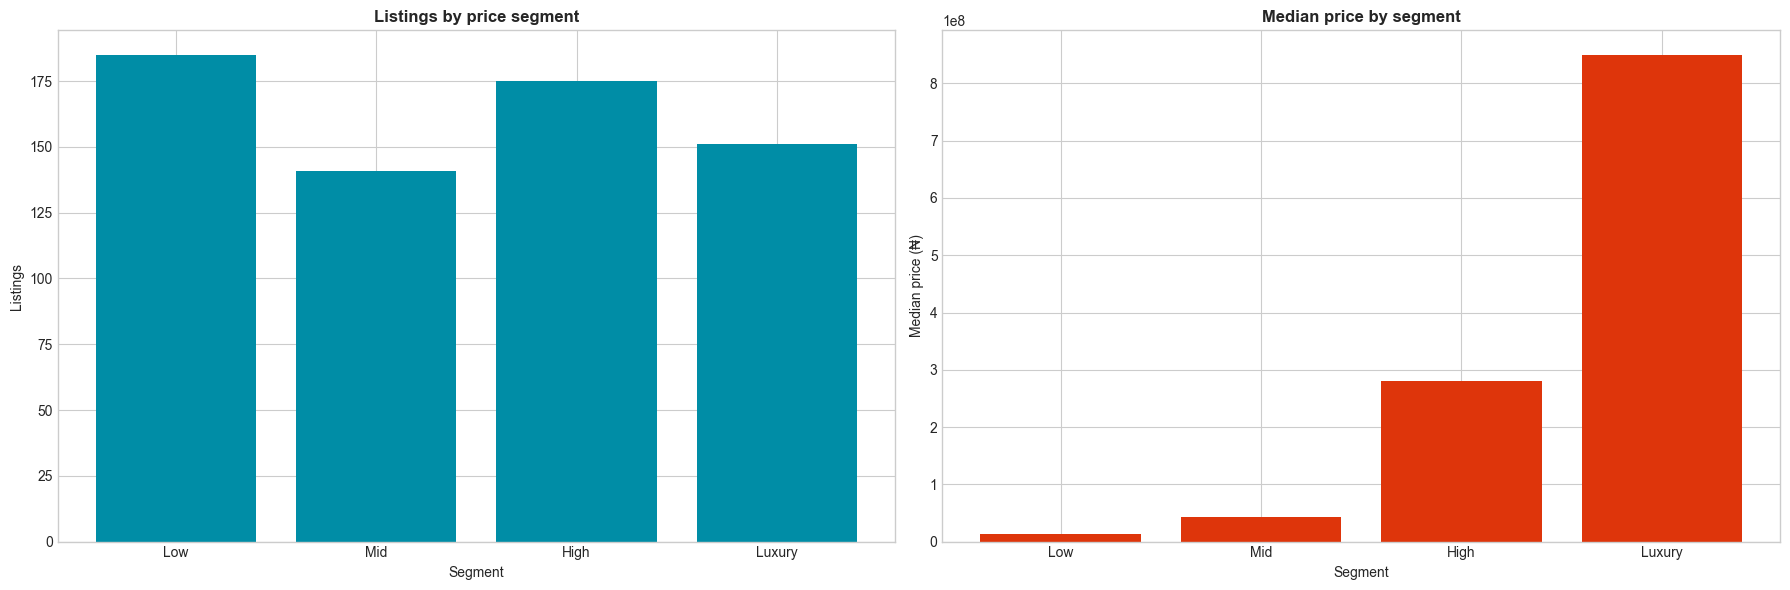

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].bar(segment_summary.index.astype(str), segment_summary['listings'].values, color=SECONDARY)
axes[0].set_title('Listings by price segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Listings')

axes[1].bar(segment_summary.index.astype(str), segment_summary['median_price'].values, color=DANGER)
axes[1].set_title('Median price by segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Median price (₦)')

plt.tight_layout()
plt.savefig('../reports/figures/listing_and_median_price_by_segment.png', dpi=300)
plt.show()

In [56]:
segment_location = (
    df_eda.groupby(['segment', 'location', 'district'], observed=True)['price']
    .median()
    .reset_index()
)
luxury_locations_tbl = segment_location[segment_location['segment'] == 'Luxury'].sort_values('price', ascending=False).head(10)
luxury_locations_tbl

,segment,location,district,price
45,Luxury,Banana Island,Ikoyi,"2,063,273,728.00"
50,Luxury,Ikoyi,Ikoyi,"1,400,000,000.00"
52,Luxury,Lekki Phase 1,Lekki,"1,300,000,000.00"
53,Luxury,Old Ikoyi,Ikoyi,"1,262,861,073.00"
59,Luxury,Victoria Island,Victoria Island,"1,000,000,000.00"
57,Luxury,Parkview,Ikoyi,"900,000,000.00"
48,Luxury,Ikate,Lekki,"850,000,000.00"
58,Luxury,Pinnock Beach Estate,Lekki,"850,000,000.00"
56,Luxury,Osapa,Lekki,"800,000,000.00"
47,Luxury,Eko Atlantic,Victoria Island,"750,000,000.00"


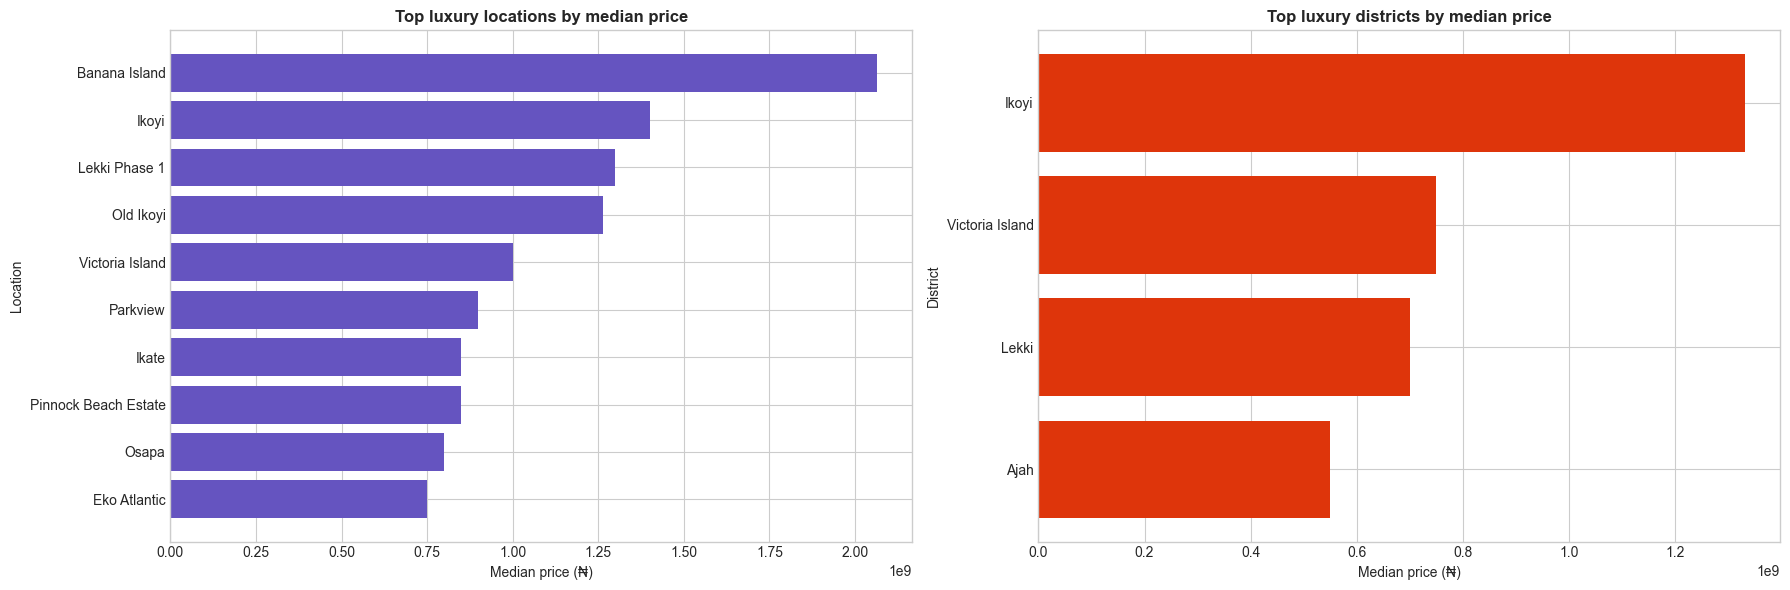

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].barh(luxury_locations_tbl['location'][::-1], luxury_locations_tbl['price'][::-1], color=HIGHLIGHT)
axes[0].set_title('Top luxury locations by median price')
axes[0].set_xlabel('Median price (₦)')
axes[0].set_ylabel('Location')

luxury_districts_tbl = (
    segment_location[segment_location['segment'] == 'Luxury']
    .groupby('district', observed=True)['price']
    .median()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
axes[1].barh(luxury_districts_tbl['district'][::-1], luxury_districts_tbl['price'][::-1], color=DANGER)
axes[1].set_title('Top luxury districts by median price')
axes[1].set_xlabel('Median price (₦)')
axes[1].set_ylabel('District')

plt.tight_layout()
plt.savefig('../reports/figures/top_luxury_locations_and_districts_by_median_price.png', dpi=300)
plt.show()

## 6. Agent activity

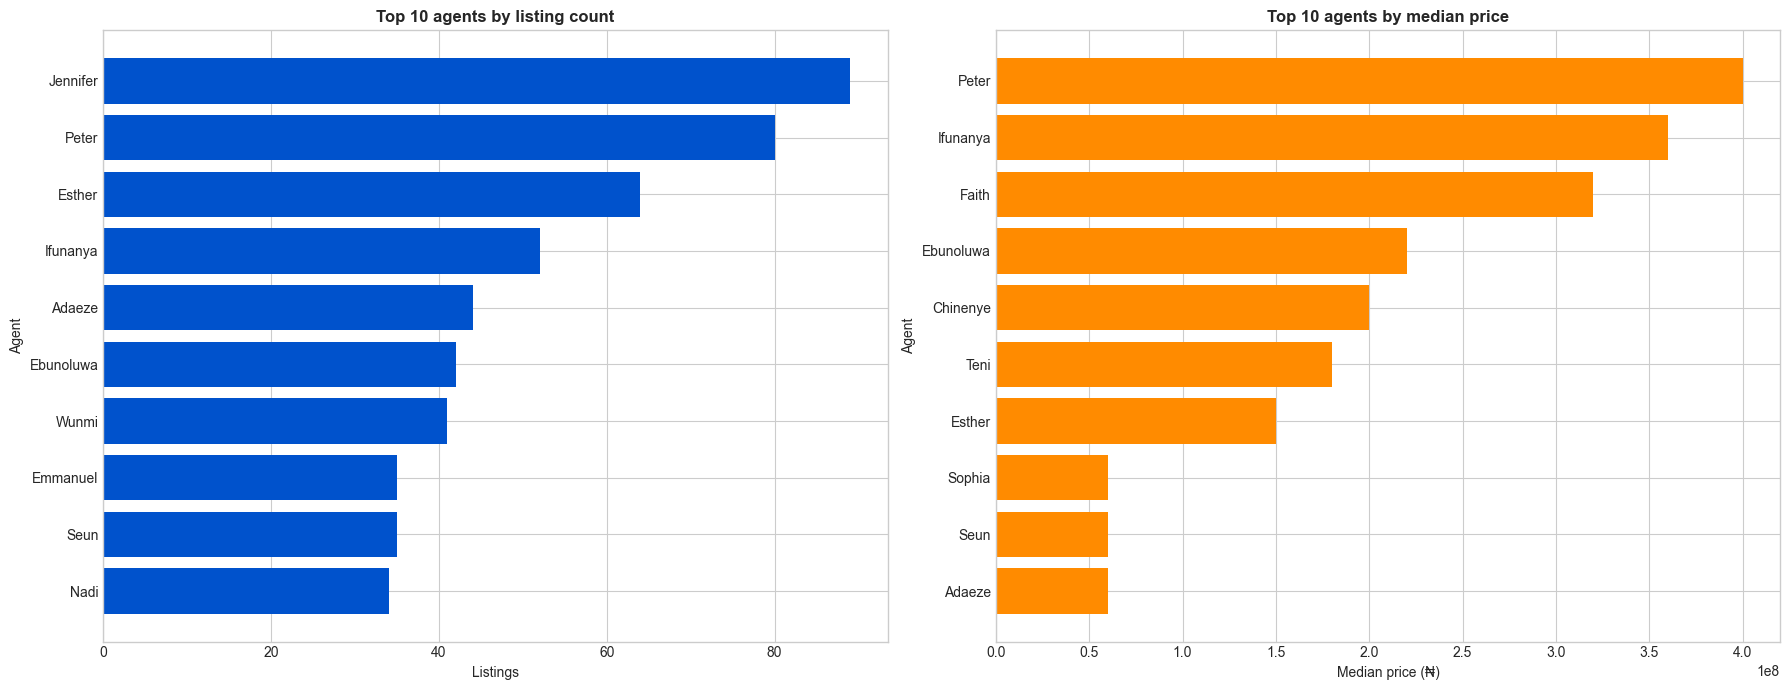

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
agent_count = agent_counts.head(10).sort_values()
axes[0].barh(agent_count.index, agent_count.values, color=PRIMARY)
axes[0].set_title('Top 10 agents by listing count')
axes[0].set_xlabel('Listings')
axes[0].set_ylabel('Agent')

agent_median = agent_medians.head(10).sort_values()
axes[1].barh(agent_median.index, agent_median.values, color=ACCENT)
axes[1].set_title('Top 10 agents by median price')
axes[1].set_xlabel('Median price (₦)')
axes[1].set_ylabel('Agent')

plt.tight_layout()
plt.savefig('../reports/figures/top_agents_by_listing_count&median_price.png', dpi = 300)
plt.show()

## 7. Correlation analysis

In [59]:
corr_cols = ['price', 'district', 'location', 'log_price']
df_temp = df_eda[corr_cols].copy()

# Encode categorical variables numerically
df_temp['district'] = pd.factorize(df_temp['district'])[0]
df_temp['location'] = pd.factorize(df_temp['location'])[0]

location_corr_matrix = df_temp.corr(numeric_only=True)
location_corr_matrix

,price,district,location,log_price
price,1.00,0.09,-0.03,0.54
district,0.09,1.00,0.17,-0.08
location,-0.03,0.17,1.00,0.00
log_price,0.54,-0.08,0.00,1.00


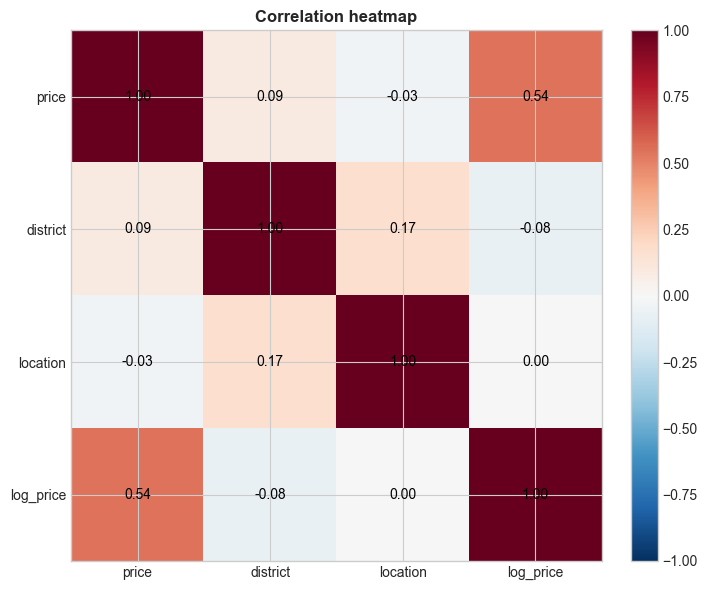

In [60]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(location_corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(location_corr_matrix.columns)))
ax.set_yticks(range(len(location_corr_matrix.index)))
ax.set_xticklabels(location_corr_matrix.columns)
ax.set_yticklabels(location_corr_matrix.index)
for i in range(len(location_corr_matrix.index)):
    for j in range(len(location_corr_matrix.columns)):
        ax.text(j, i, f'{location_corr_matrix.values[i, j]:.2f}', ha='center', va='center', color='black')
ax.set_title('Correlation heatmap')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('../reports/figures/location_correlation_heatmap.png', dpi = 300)
plt.show()

In [61]:
corr_cols = ['price', 'beds', 'baths', 'log_price']
corr_matrix = df_eda[corr_cols].corr(numeric_only=True)
corr_matrix

,price,beds,baths,log_price
price,1.00,0.16,0.16,0.54
beds,0.16,1.00,1.00,0.36
baths,0.16,1.00,1.00,0.36
log_price,0.54,0.36,0.36,1.00


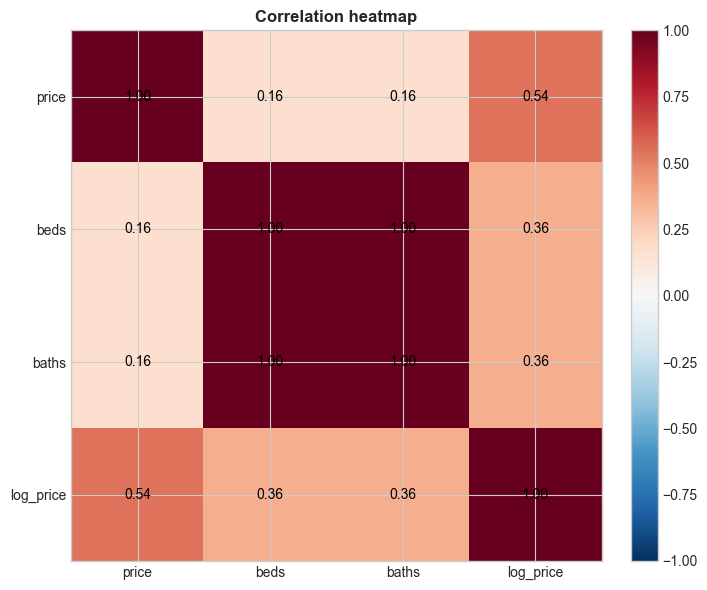

In [62]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.index)
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f'{corr_matrix.values[i, j]:.2f}', ha='center', va='center', color='black')
ax.set_title('Correlation heatmap')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('../reports/figures/room_correlation_heatmap.png', dpi = 300)
plt.show()

## 8. Luxury market investigation

In [63]:
luxury_df = df_eda[df_eda['price'] >= luxury_threshold].copy()
print(f'Luxury threshold (top 1%): ₦{luxury_threshold:,.0f}')
print(f'Luxury listings: {len(luxury_df):,}')
luxury_df[['title', 'location', 'district', 'kind', 'beds', 'baths', 'price']].sort_values('price', ascending=False).head(10)

Luxury threshold (top 1%): ₦4,647,000,000
Luxury listings: 7


,title,location,district,kind,beds,baths,price
317,Land Measuring 16300sqm- Ajah,Ajah,Ajah,Mixed-Use Land,0.00,0.00,"15,000,000,000.00"
208,5-Bedroom Waterfront Duplex in Ikoyi,Banana Island,Ikoyi,Detached Duplex,5.00,5.00,"11,004,126,547.00"
412,5-bedroom detached mansion +2Bq in Ikoyi,Ikoyi,Ikoyi,Detached Duplex,5.00,5.00,"11,004,126,547.00"
85,Land Measuring 3334sqm in VI,Victoria Island,Victoria Island,Mixed-Use Land,0.00,0.00,"8,500,000,000.00"
268,Land Measuring 1200sqm- Ikoyi,Ikoyi,Ikoyi,Residential Land,0.00,0.00,"5,400,000,000.00"
339,5-Bedroom Detached Duplex in Ikoyi,Banana Island,Ikoyi,Detached Duplex,5.00,5.00,"4,814,305,365.00"
380,5-Bedroom Detached Residence- Ikoyi,Ikoyi,Ikoyi,Detached Duplex,5.00,5.00,"4,800,000,000.00"


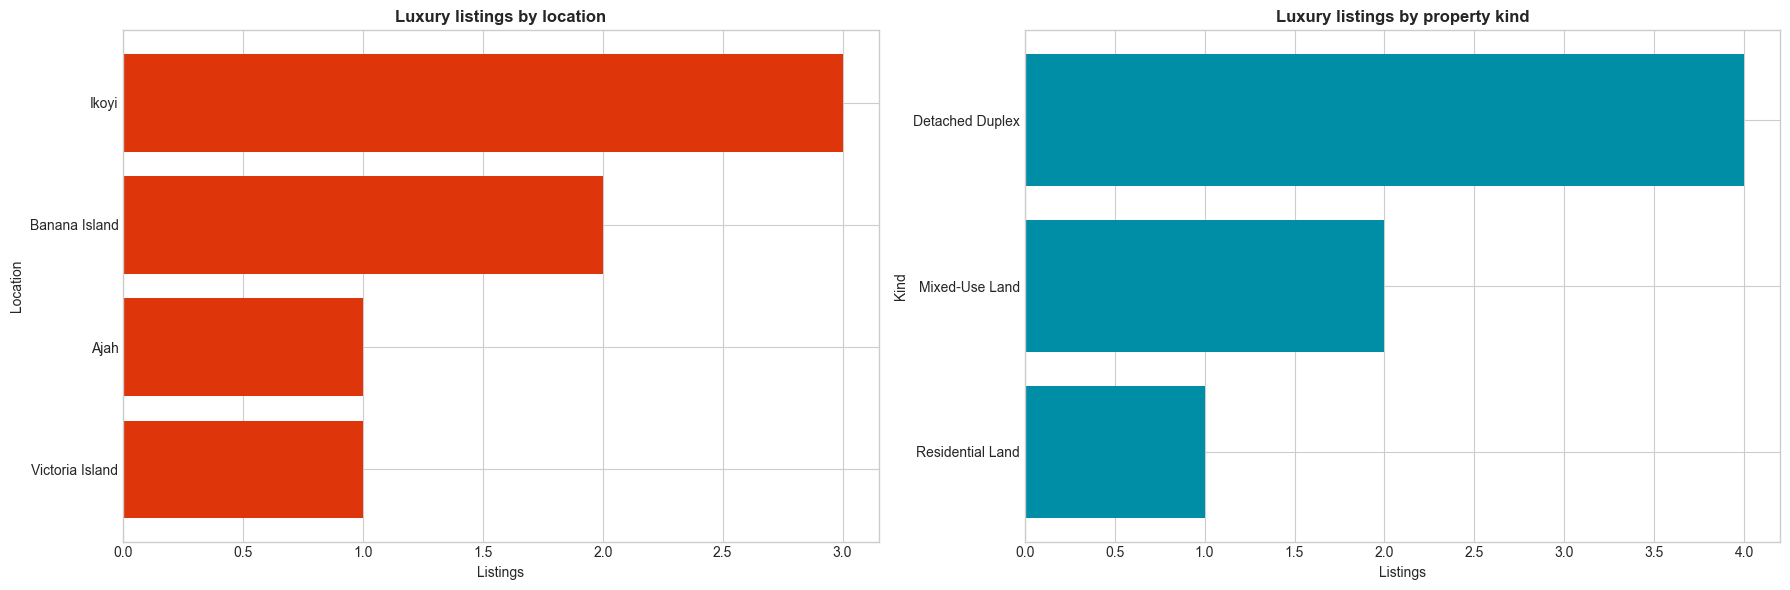

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
lux_loc = luxury_df['location'].value_counts().head(10).sort_values()
axes[0].barh(lux_loc.index, lux_loc.values, color=DANGER)
axes[0].set_title('Luxury listings by location')
axes[0].set_xlabel('Listings')
axes[0].set_ylabel('Location')

lux_kind = luxury_df['kind'].value_counts().sort_values()
axes[1].barh(lux_kind.index, lux_kind.values, color=SECONDARY)
axes[1].set_title('Luxury listings by property kind')
axes[1].set_xlabel('Listings')
axes[1].set_ylabel('Kind')

plt.tight_layout()
plt.savefig('../reports/figures/luxury_listing_by_locations&kind.png', dpi = 300)
plt.show()

## 9. Key insights and conclusion

- The dataset contains **652 listings** after removing duplicated listing URLs.
- Prices are heavily skewed: the **median price is ₦115,020,632**, with Q1 at **₦25,000,000** and Q3 at **₦450,000,000**.
- The market is concentrated in **Lekki**, **Ikoyi**, and **Victoria Island** districts.
- **Lekki Phase 1** has the highest listing concentration, while **Pinnock Beach Estate** has the highest median asking price among locations.
- Apartments are the most common property kind, but **Maisonette** commands the highest median price.
- The top 1% luxury threshold sits at about **₦4,647,000,000**, and luxury listings cluster in premium locations like **Ikoyi, Banana Island, Victoria Island, Ajah**.
- Bedrooms and bathrooms are positively related to price, but the strongest signal here is still location and property class.

**Bottom line:** Lagos real estate in this sample is a concentrated, premium-heavy market with sharp location effects, a long luxury tail, and clear segmentation between affordable, mid-market, and ultra-premium listings.